# Pass Visualisation

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import pandas as pd
import networkx as nx
from IPython.display import Image

from src.pitch import draw_pitch
from src.viz import get_pass_snapshot, get_trajectories, draw_prediction_overlay
from src.build_dataset import MatchPositions, build_kickoff_lookup, load_base_tables, attack_flip
from src.train import set_all_seeds, SEED, train_model, predict_with_model
from src.parse import OUT_DIR

DEMO_MATCH = "J03WOH"

In [2]:
events, players, matches = load_base_tables()
second_half_cutoff, team_left_by_match_half = build_kickoff_lookup(events)
match_pos = MatchPositions(DEMO_MATCH)
team_of_in_match = players.loc[players["match_id"] == DEMO_MATCH].set_index("person_id")["team_id"].to_dict()
name_of = players.groupby("person_id")["name"].first()

print(matches.loc[matches["match_id"] == DEMO_MATCH,
                   ["home_team_name", "away_team_name", "result"]].to_string(index=False))

    home_team_name      away_team_name result
Fortuna Düsseldorf SSV Jahn Regensburg    4:0


## Single pass snapshot
* Passer team in red
* Passer as gold
* Opponent as blue
* black arrow to actucal Recipient 

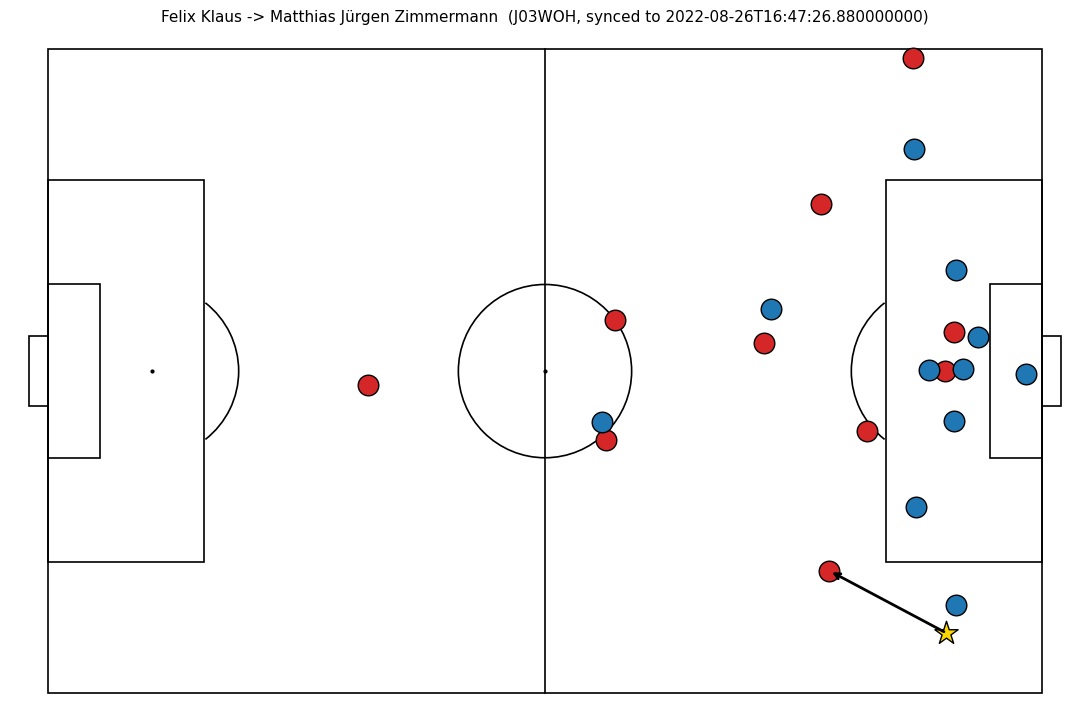

In [3]:
from src.viz import draw_players, draw_pass_arrow

DEMO_PASS_ID = 18232100000212

pass_row = events[events["event_id"] == DEMO_PASS_ID].iloc[0]
snap, synced_ts, flip = get_pass_snapshot(pass_row, match_pos, team_of_in_match,
                                           second_half_cutoff, team_left_by_match_half)

fig, ax = plt.subplots(figsize=(11, 7.5))
draw_pitch(ax)
draw_players(ax, snap)
draw_pass_arrow(ax, snap)
passer_name = name_of[pass_row["player_id"]]
recipient_name = name_of[pass_row["recipient_id"]]
ax.set_title(f"{passer_name} -> {recipient_name}  ({DEMO_MATCH}, synced to {synced_ts})", fontsize=11)
fig.tight_layout()
plt.show()

## Model prediction overlay: 3 confidently-correct, 3 confidently-wrong


In [7]:
set_all_seeds(SEED)
df = pd.read_parquet(f"{OUT_DIR}/pass_candidates.parquet")
max_cand = df.groupby("pass_id").size().max()
train_df = df[df["match_id"] != DEMO_MATCH]
test_df = df[df["match_id"] == DEMO_MATCH]

model, means, stds = train_model(train_df, max_cand)
pred = predict_with_model(model, test_df, max_cand, means, stds)
pred["is_top1"] = pred.groupby("pass_id")["prob"].transform("max") == pred["prob"]

correct_ids = (pred[pred["is_top1"] & (pred["is_recipient"] == 1)]
               .sort_values("prob", ascending=False)["pass_id"].head(3).tolist())
wrong_ids = (pred[pred["is_top1"] & (pred["is_recipient"] == 0)]
             .sort_values("prob", ascending=False)["pass_id"].head(3).tolist())

top1_acc_this_match = pred.groupby("pass_id").apply(
    lambda g: g.loc[g["prob"].idxmax(), "is_recipient"] == 1, include_groups=False).mean()
print(f"top-1 accuracy on {DEMO_MATCH} (this fold): {top1_acc_this_match:.1%} "
      f"({pred['pass_id'].nunique()} passes)")

top-1 accuracy on J03WOH (this fold): 40.4% (581 passes)


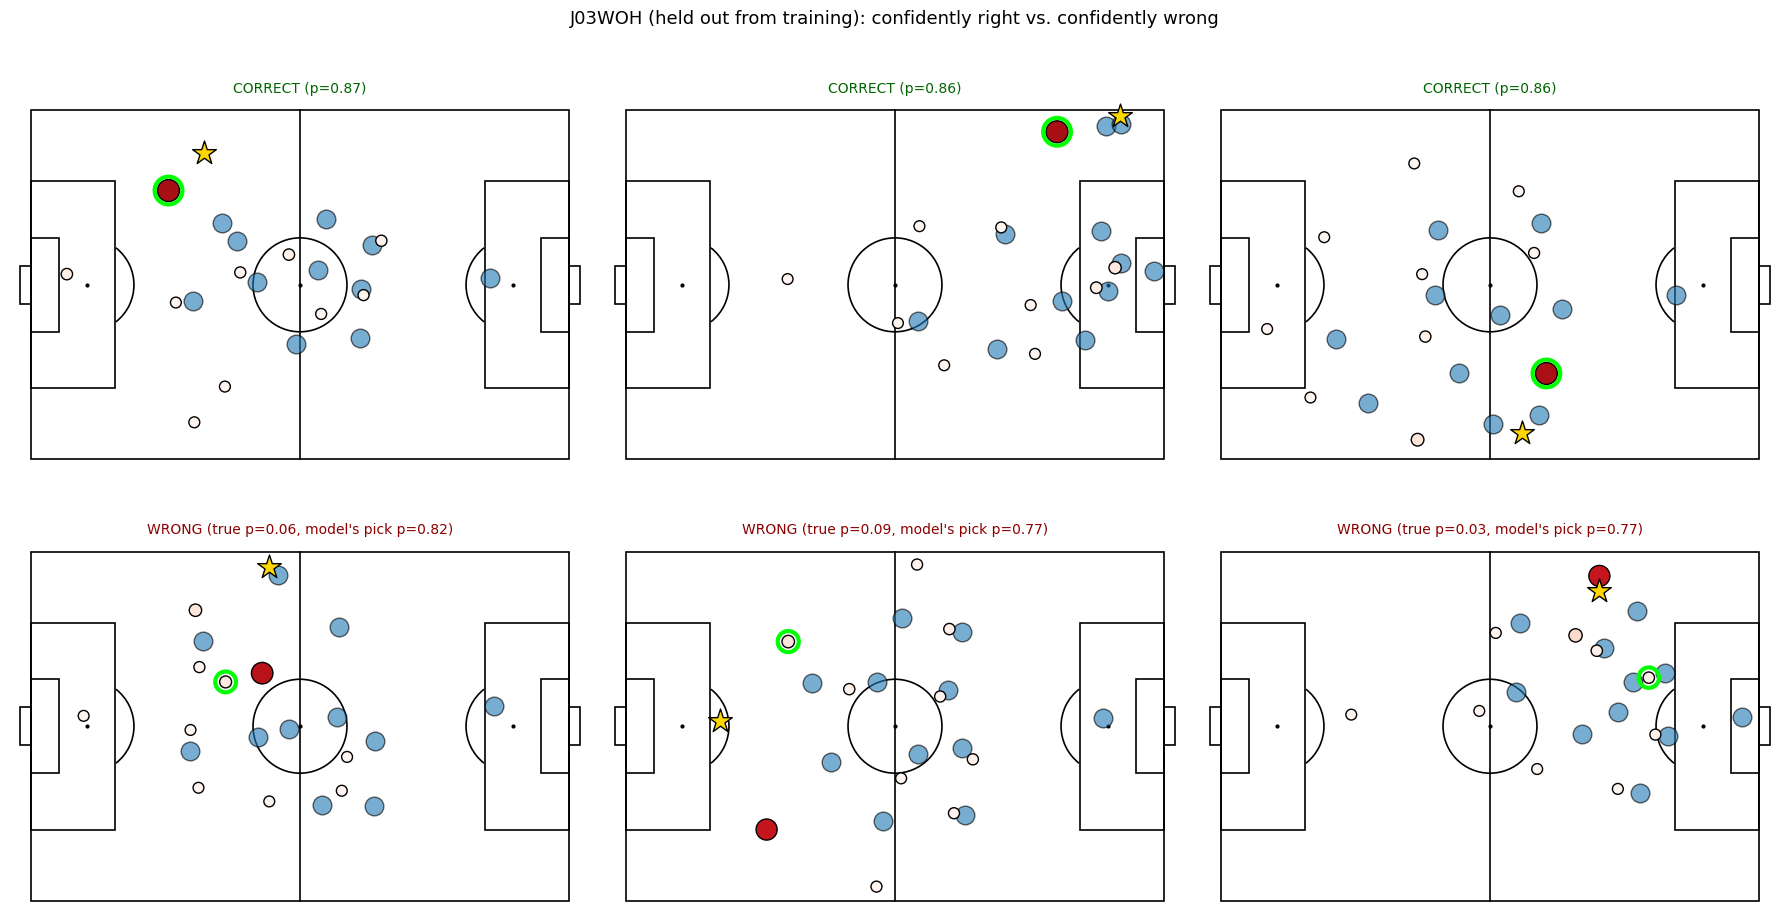

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for col, pid in enumerate(correct_ids):
    ax = axes[0, col]
    draw_pitch(ax)
    prow = events[events["event_id"] == pid].iloc[0]
    snap, _, _ = get_pass_snapshot(prow, match_pos, team_of_in_match, second_half_cutoff, team_left_by_match_half)
    this_pred = pred[pred["pass_id"] == pid]
    true_prob = this_pred.loc[this_pred["is_recipient"] == 1, "prob"].iloc[0]
    draw_prediction_overlay(ax, snap, this_pred, marker_size_scale= 220, marker_size_base=60)
    ax.set_title(f"CORRECT (p={true_prob:.2f})", fontsize=10, color="darkgreen")
for col, pid in enumerate(wrong_ids):
    ax = axes[1, col]
    draw_pitch(ax)
    prow = events[events["event_id"] == pid].iloc[0]
    snap, _, _ = get_pass_snapshot(prow, match_pos, team_of_in_match, second_half_cutoff, team_left_by_match_half)
    this_pred = pred[pred["pass_id"] == pid]
    true_prob = this_pred.loc[this_pred["is_recipient"] == 1, "prob"].iloc[0]
    top_prob = this_pred["prob"].max()
    draw_prediction_overlay(ax, snap, this_pred, marker_size_scale= 220, marker_size_base=60)
    ax.set_title(f"WRONG (true p={true_prob:.2f}, model's pick p={top_prob:.2f})", fontsize=10, color="darkred")
fig.suptitle(f"{DEMO_MATCH} (held out from training): confidently right vs. confidently wrong", fontsize=13)
fig.tight_layout()
plt.show()

##  Trajectory context


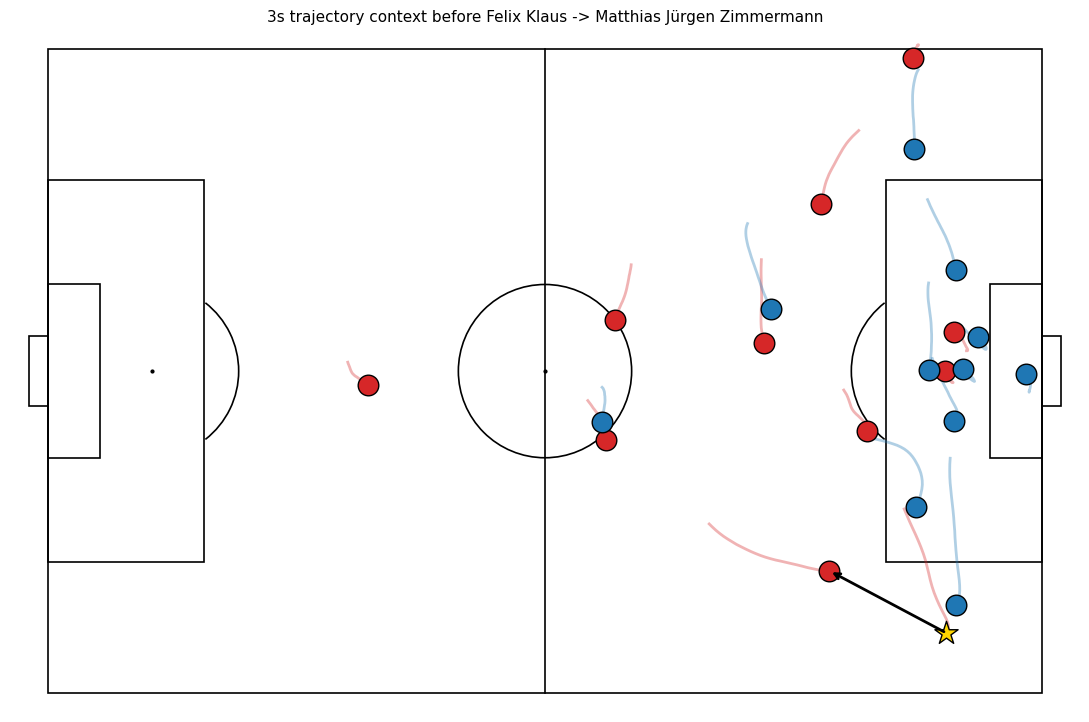

In [10]:
from src.viz import draw_trails

pass_row = events[events["event_id"] == DEMO_PASS_ID].iloc[0]
snap, synced_ts, flip = get_pass_snapshot(pass_row, match_pos, team_of_in_match,
                                           second_half_cutoff, team_left_by_match_half)
trails = get_trajectories(snap["person_id"], match_pos, synced_ts, flip, window_s=3.0)

fig, ax = plt.subplots(figsize=(11, 7.5))
draw_pitch(ax)
draw_trails(ax, snap, trails)
draw_players(ax, snap)
draw_pass_arrow(ax, snap)
ax.set_title(f"3s trajectory context before {passer_name} -> {recipient_name}", fontsize=11)
fig.tight_layout()
plt.show()